In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
#import cartopy.io.shapereader as reader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 1. Open the GRIB file with the filter that worked
ds = xr.open_dataset(
    'surface.grib', 
    engine='cfgrib', 
    backend_kwargs={'filter_by_keys': {'typeOfLevel': 'surface'}}
)

# 2. Extract the specific time: April 28, 2011 at 00:00 UTC
# Using .sel(time=...) handles the extraction from the 'time' dimension
target_time = '2011-04-28T00:00:00'
ds_00z = ds.sel(time=target_time)

# 3. Fix Longitude for Cartopy (-180 to 180)
# ERA5 defaults to 0-360; this shift aligns it with your shapefiles
ds_00z.coords['longitude'] = (dtemperature_2ms_00z.coords['longitude'] + 180) % 360 - 180
ds_00z = ds_00z.sortby('longitude')

# 4. Subset for the Southeast US (Matches your WRF/Pangu plots)
lat_slice = slice(50, 25)   # North to South
lon_slice = slice(-125, -65) # West to East

ds_final = ds_00z.sel(latitude=lat_slice, longitude=lon_slice)

# 5. Save to NetCDF
output_name = 'era5_2011-04-28_00z_subset.nc'
ds_final.to_netcdf(output_name)

print(f"Successfully saved {output_name}")

NameError: name 'dtemperature_2ms_00z' is not defined

In [12]:
import xarray as xr

# Use 'filter_by_keys' to isolate the surface data
# This prevents the empty dataset error by selecting only the 2m Temp layer
ds = xr.open_dataset(
    'surface.grib', 
    engine='cfgrib', 
    backend_kwargs={'filter_by_keys': {'typeOfLevel': 'surface'}}
)

# Now check if variables exist
print(ds.data_vars)

Data variables:
    u10      (time, latitude, longitude) float32 66MB ...
    v10      (time, latitude, longitude) float32 66MB ...
    d2m      (time, latitude, longitude) float32 66MB ...
    t2m      (time, latitude, longitude) float32 66MB ...
    sst      (time, latitude, longitude) float32 66MB ...
    sp       (time, latitude, longitude) float32 66MB ...
    msl      (time, latitude, longitude) float32 66MB ...
    skt      (time, latitude, longitude) float32 66MB ...
    lsm      (time, latitude, longitude) float32 66MB ...
    siconc   (time, latitude, longitude) float32 66MB ...
    z        (time, latitude, longitude) float32 66MB ...
    rsn      (time, latitude, longitude) float32 66MB ...
    sd       (time, latitude, longitude) float32 66MB ...


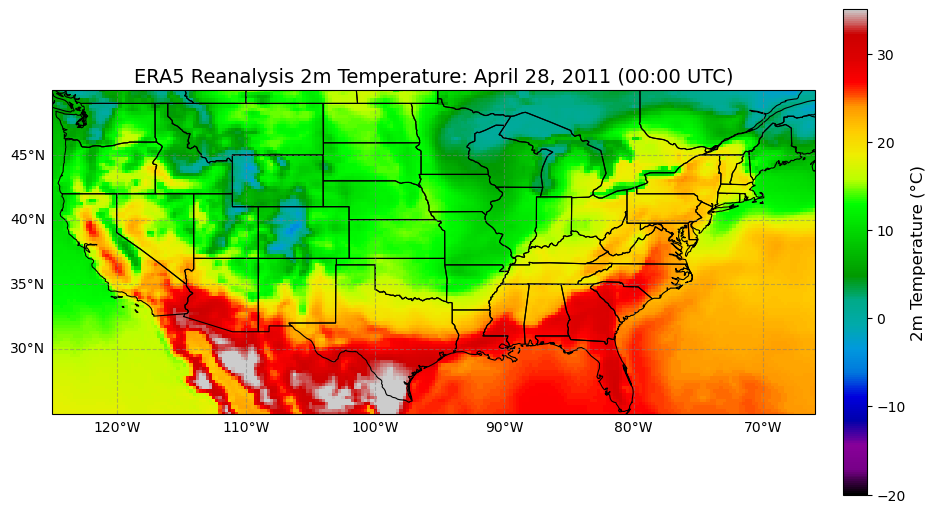

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
#import cartopy.io.shapereader as reader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Load the new subset
ds_plot = xr.open_dataset('era5_2011-04-28_00z_subset.nc')
t2m_c = ds_plot['t2m'] - 273.15  # Convert Kelvin to Celsius


# Define universal constants for both plots
T_MIN, T_MAX = -20, 35

fig = plt.figure(figsize=(12, 9)) # Use same figsize as WRF
ax = plt.axes(projection=ccrs.PlateCarree())

# Add State Lines
# Add the Local State Lines
shp_path = 'state_lines/ne_50m_admin_1_states_provinces.shp'
reader = shpreader.Reader(shp_path)
ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), 
                  facecolor='none', edgecolor='black', linewidth=0.8)

# Plot with SAME FIXED LIMITS
mesh = t2m_c.plot(
    ax=ax, 
    transform=ccrs.PlateCarree(), 
    cmap='nipy_spectral',
    vmin=T_MIN,      # Must match WRF
    vmax=T_MAX,      # Must match WRF
    add_colorbar=False 
)

# Use the FIG object here too
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', pad=0.03, shrink=0.7)
cbar.set_label('2m Temperature (°C)', fontsize=12)

# Standardize the map zoom (Extents) to match WRF exactly
ax.set_extent([-125, -66, 25, 50], crs=ccrs.PlateCarree())

# Formatting
gl = ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False, 
                  linestyle='--', color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title("ERA5 Reanalysis 2m Temperature: April 28, 2011 (00:00 UTC)", fontsize=14)
plt.show()